### Imports:

In [2]:
import numpy as np
import pandas as pd

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import distclassipy as dcpy
from distclassipy.anomaly import DistanceAnomaly

import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np
from relaiss import constants
import relaiss as rl
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")

### Load data

In [4]:
csv_path = "/Users/jennakempster-taylor/re-laiss/reference_20k_with_durations.csv" 

# Load
df = pd.read_csv(csv_path, low_memory=False)


# Grab our RELAISS features
default_lc_features = constants.lc_features_const.copy()
default_host_features = constants.host_features_const.copy()

# quick look at what is included
print("Default LC features (sample):", default_lc_features)
print("Default host features (sample):", default_host_features)


Default LC features (sample): ['g_peak_time', 'r_peak_time', 'g_rise_time', 'g_decline_time', 'r_rise_time', 'r_decline_time', 'g_duration_above_half_flux', 'r_duration_above_half_flux', 'g_amplitude', 'r_amplitude', 'g_skewness', 'r_skewness', 'g_beyond_2sigma', 'r_beyond_2sigma', 'mean_g-r', 'g-r_at_g_peak', 'mean_color_rate', 'g_max_rolling_variance', 'r_max_rolling_variance', 'g_mean_rolling_variance', 'r_mean_rolling_variance', 'g_rise_local_curvature', 'g_decline_local_curvature', 'r_rise_local_curvature', 'r_decline_local_curvature']
Default host features (sample): ['gKronMagCorrected', 'gKronRad', 'gExtNSigma', 'rKronMagCorrected', 'rKronRad', 'rExtNSigma', 'iKronMagCorrected', 'iKronRad', 'iExtNSigma', 'zKronMagCorrected', 'zKronRad', 'zExtNSigma', 'gminusrKronMag', 'rminusiKronMag', 'iminuszKronMag', 'rmomentXX', 'rmomentXY', 'rmomentYY']


In [5]:
# Cut
from astropy.coordinates import SkyCoord
import astropy.units as u

# Apply cut to original df 
df = pd.read_csv(csv_path, low_memory=False)

coords = SkyCoord(ra=df["ra"].values * u.deg,
                  dec=df["dec"].values * u.deg,
                  frame="icrs")

b = coords.galactic.b.deg  # Galactic latitude

# Duration cut
mask_duration = df["duration_days"] <= 200

# Galactic latitude cut exclude plane |b| < 15 degrees
LAT_CUT = 15.0
mask_lat = np.abs(b) >= LAT_CUT

# Combine both
mask = mask_duration & mask_lat
df_cut = df[mask].copy()

print(f"Filtered dataset: {len(df_cut)} rows (out of {len(df)})")
print(f"Removed due to long duration or near galactic plane: {(~mask).sum()}")


Filtered dataset: 17254 rows (out of 25515)
Removed due to long duration or near galactic plane: 8261


In [8]:
USE_HOST = False  # use only light curves initially

def overlap(cols, frame):
    # keep only columns present and drop *_err 
    return [c for c in cols if (c in frame.columns) and (not c.endswith("_err"))]

lc_cols   = overlap(default_lc_features, df_cut)
host_cols = overlap(default_host_features, df_cut) if USE_HOST else []
feature_cols = ["ZTFID"] + lc_cols + host_cols

print(f"Found {len(lc_cols)} LC features in filtered data.")
if USE_HOST:
    print(f"Found {len(host_cols)} host features in filtered data.")
print(f"Total candidate features: {len(feature_cols)}")

from sklearn.impute import KNNImputer

# Ensure all is nnumeric:
numeric_feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_cut[c])]
X = df_cut[numeric_feature_cols].replace([np.inf, -np.inf], np.nan)
knn_imp = KNNImputer(n_neighbors=5, weights="uniform")
X_imp = knn_imp.fit_transform(X)

print(f"X shape: {X.shape}  -> after KNN impute: {X_imp.shape}")

Found 25 LC features in filtered data.
Total candidate features: 26
X shape: (17254, 25)  -> after KNN impute: (17254, 25)


In [9]:
df_cut.columns

Index(['t0', 'g_peak_mag', 'g_peak_time', 'g_rise_time', 'g_decline_time',
       'g_duration_above_half_flux', 'g_amplitude', 'g_skewness',
       'g_beyond_2sigma', 'r_peak_mag',
       ...
       'mjd_extracted', 'tns_redshift', 'latest_magnitude', 'oldest_alert',
       'newest_alert', 'peak_phase', 'antares_oldest_alert',
       'antares_newest_alert', 'antares_duration', 'duration_days'],
      dtype='object', length=462)

In [10]:
# Standardise

scaler = StandardScaler()
X_std = scaler.fit_transform(X_imp)

In [11]:
# Cross reference for classes from ZTF data:
import os
os.getcwd()
os.listdir("experiments")
zdf = pd.read_csv("experiments/explorer.csv")
#zdf


In [12]:
df_cut["ZTFID"] = df_cut["ZTFID"].astype(str)
zdf["ZTFID"] = zdf["ZTFID"].astype(str)

zdf_subset = zdf[["ZTFID", "type"]]
df_matched = df_cut.merge(zdf_subset, on="ZTFID", how="left")

df_matched["ZTFID"].notna().sum(), len(df_matched)
df_matched[df_matched["ZTFID"].notna()].head()


,t0,g_peak_mag,g_peak_time,g_rise_time,g_decline_time,g_duration_above_half_flux,g_amplitude,g_skewness,g_beyond_2sigma,r_peak_mag,...,tns_redshift,latest_magnitude,oldest_alert,newest_alert,peak_phase,antares_oldest_alert,antares_newest_alert,antares_duration,duration_days,type
0,59850.515694,18.058201,19.991794,6.032847,12.011400,18.044248,0.521299,0.225308,0.0,17.598600,...,NaN,NaN,NaN,NaN,NaN,59850.515694,59901.530729,51.015035,51.015035,SN Ia
1,60596.327662,16.803886,9.917465,8.474729,14.790803,16.114167,3.273268,0.270541,0.0,17.555490,...,NaN,NaN,NaN,NaN,NaN,60596.327662,60663.246713,66.919051,66.919051,SN Ia
2,59861.468773,18.025000,0.000000,NaN,1.246246,5.971481,1.945101,0.815205,0.1,18.274099,...,NaN,NaN,NaN,NaN,NaN,59861.468773,59874.486111,13.017338,13.017338,NaN
3,60168.430151,19.891600,16.017986,16.017986,NaN,16.017986,0.332001,0.738549,0.0,19.139200,...,NaN,NaN,NaN,NaN,NaN,60168.430151,60208.496088,40.065937,40.065937,NaN
4,59163.441424,NaN,NaN,NaN,NaN,NaN,0.089211,-0.370045,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,59163.441424,59170.444711,7.003287,7.003287,NaN


In [87]:
# ZTFID not working for matching so using coords instead

In [18]:
from astropy.coordinates import SkyCoord
import astropy.units as u

alerce_coords = SkyCoord(
    ra=zdf["RA"].astype(str),
    dec=zdf["Dec"].astype(str),
    unit=(u.hourangle, u.deg)
)

zdf["ra_deg"] = alerce_coords.ra.deg
zdf["dec_deg"] = alerce_coords.dec.deg


In [20]:
ref_coords = SkyCoord(
    ra=df_cut["ra"].values * u.deg,
    dec=df_cut["dec"].values * u.deg
)

idx, sep, _ = ref_coords.match_to_catalog_sky(alerce_coords)

mask = sep < 1 * u.arcsec


In [22]:
df_cut["alerce_idx"] = idx
df_cut["matched"] = mask

df_matched = df_cut[mask].copy()

df_matched = df_matched.merge(
    zdf[["ra_deg", "dec_deg", "ZTFID", "type", "IAUID"]],
    left_on="alerce_idx",
    right_index=True,
    how="left"
)
#print(df_cut.iloc[0])
#print(zdf.iloc[0])

In [24]:
num_matched = df_cut["matched"].sum()
num_total   = len(df_cut)
num_unmatched = num_total - num_matched

print("Matched:", num_matched)
print("Unmatched:", num_unmatched)
print("Total:", num_total)

Matched: 2730
Unmatched: 14524
Total: 17254


In [89]:
df_matched.to_csv("reference_matched_with_alerce.csv", index=False)
df_unmatched = df_cut[~df_cut["matched"]]
df_unmatched.to_csv("reference_unmatched_for_dimmad.csv", index=False)

### Now examine cross-matched data

In [101]:
df_matched   = pd.read_csv("reference_matched_with_alerce.csv")
df_unmatched = pd.read_csv("reference_unmatched_for_dimmad.csv")

print("Objects with type defined:", df_matched["type"].notna().sum())

print("Name of different types:", np.unique(df_matched["type"].dropna()))

print("Counts of each type:", df_matched["type"].value_counts())

Objects with type defined: 2730
Name of different types: ['SLSN-I' 'SLSN-II' 'SN II' 'SN II-pec' 'SN IIP' 'SN IIb' 'SN IIn' 'SN Ia'
 'SN Ia-91T' 'SN Ia-91bg' 'SN Ia-CSM' 'SN Ia-SC' 'SN Ia-pec' 'SN Iax'
 'SN Ib' 'SN Ib-pec' 'SN Ib/c' 'SN Ibn' 'SN Ic' 'SN Ic-BL' 'SN Icn' 'TDE'
 'TDE-He']
Counts of each type: type
SN Ia         2039
SN II          307
SN Ia-91T       53
SN Ic           52
SN IIn          49
SN Ib           44
SN IIb          41
SN Ic-BL        22
SLSN-I          15
TDE             15
SN Ia-pec       15
SN Ia-91bg      14
SN IIP          12
SN Ibn          10
SLSN-II          9
SN Ib/c          7
SN Iax           6
SN Ia-SC         6
SN Icn           4
SN Ia-CSM        4
SN II-pec        3
TDE-He           2
SN Ib-pec        1
Name: count, dtype: int64


In [105]:
def map_type(t):
    if pd.isna(t):
        return np.nan

    t = t.strip()

    # SLSN
    if t in ['SLSN-I', 'SLSN-II']:
        return 'SLSN'

    # Type II-P
    if t in ['SN II', 'SN II-pec', 'SN IIP']:
        return 'IIP'

    # Type IIb
    if t == 'SN IIb':
        return 'IIb'

    # Type IIn
    if t == 'SN IIn':
        return 'IIn'

    # Type Ia family
    if t in ['SN Ia', 'SN Ia-91T', 'SN Ia-91bg', 'SN Ia-SC', 'SN Iax']:
        return 'Ia'

    # Type Ibc family
    if t in ['SN Ib', 'SN Ib/c', 'SN Ic', 'SN Ic-BL']:
        return 'Ibc'

    # TDE
    if t in ['TDE', 'TDE-He']:
        return 'TDE'

    # Weird, exclude from "known"
    if t in ['Ia-pec', 'Ia-CSM', 'SN Ib-pec', 'Ibn', 'Icn']:
        return 'REMOVE'

    # Everything else
    return 'UNKNOWN'

# Apply to your dataframe
df_matched["type_group"] = df_matched["type"].apply(map_type)

In [107]:
df_matched["type_group"].value_counts()

type_group
Ia         2118
IIP         322
Ibc         125
IIn          49
IIb          41
UNKNOWN      33
SLSN         24
TDE          17
REMOVE        1
Name: count, dtype: int64

### DiMMAD med-med:

In [111]:
df_matched = pd.read_csv("reference_matched_with_alerce.csv")
df_unmatched = pd.read_csv("reference_unmatched_for_dimmad.csv")

df_matched["type_group"] = df_matched["type"].apply(map_type)

known_groups = ["SLSN", "IIP", "IIb", "IIn", "Ia", "Ibc", "TDE"]
df_train = df_matched[df_matched["type_group"].isin(known_groups)]
df_anom  = pd.concat([
    df_unmatched,
    df_matched[df_matched["type_group"] == "UNKNOWN"]
], ignore_index=True)


In [113]:
len(df_train), len(df_anom)

(2696, 14557)

In [117]:
feature_cols = [c for c in feature_cols if c in df_train.columns]
print("Using features:", feature_cols)

Using features: ['g_peak_time', 'r_peak_time', 'g_rise_time', 'g_decline_time', 'r_rise_time', 'r_decline_time', 'g_duration_above_half_flux', 'r_duration_above_half_flux', 'g_amplitude', 'r_amplitude', 'g_skewness', 'r_skewness', 'g_beyond_2sigma', 'r_beyond_2sigma', 'mean_g-r', 'g-r_at_g_peak', 'mean_color_rate', 'g_max_rolling_variance', 'r_max_rolling_variance', 'g_mean_rolling_variance', 'r_mean_rolling_variance', 'g_rise_local_curvature', 'g_decline_local_curvature', 'r_rise_local_curvature', 'r_decline_local_curvature']


In [121]:
df_train_clean = df_train.dropna(subset=feature_cols)
df_anom_clean  = df_anom.dropna(subset=feature_cols)

print("Train:", len(df_train), "→", len(df_train_clean))
print("Anomaly set:", len(df_anom), "→", len(df_anom_clean))

Train: 2696 → 1649
Anomaly set: 14557 → 3427


In [125]:
X_train_raw = df_train[feature_cols].copy()
X_anom_raw  = df_anom[feature_cols].copy()

imputer = KNNImputer(n_neighbors=5, weights="distance")
X_train_imputed = imputer.fit_transform(X_train_raw)
X_anom_imputed  = imputer.transform(X_anom_raw)

In [127]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_imputed)
X_anom  = scaler.transform(X_anom_imputed)

In [190]:
X_train = X_train  
y_train = df_train["type_group"].values

dimmad_medmed = DistanceAnomaly(
    cluster_agg='median',
    metric_agg='median',
    normalize_scores=True
)

dimmad_medmed.fit(X_train, y_train)
scores_medmed = dimmad_medmed.score_samples(X_anom)
df_anom["dimmad_score"] = scores_medmed

In [143]:
df_ranked = df_anom.sort_values("dimmad_score", ascending=False)
df_ranked.head()

,t0,g_peak_mag,g_peak_time,g_rise_time,g_decline_time,g_duration_above_half_flux,g_amplitude,g_skewness,g_beyond_2sigma,r_peak_mag,...,alerce_idx,matched,ZTFID_x,ra_deg,dec_deg,ZTFID_y,type,IAUID,type_group,dimmad_score
1362,59188.172083,18.701599,8.965845,7.574882,17.861326,11.055648,1.741201,0.479902,0.0,18.665045,...,1354,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000049
10425,60181.368044,19.278500,10.971331,8.805113,12.451173,18.099086,1.223301,0.190322,0.0,19.156700,...,2291,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000164
6757,59747.326817,19.102888,8.970868,6.677856,16.319233,19.997199,1.610811,0.403254,0.0,19.049553,...,946,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000176
6643,59734.195058,18.914310,9.084005,5.113509,15.097768,20.020625,1.645590,0.307924,0.0,18.748154,...,2970,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000200
1157,59168.212199,18.928694,9.171516,7.650648,17.337440,17.966528,1.376257,0.563866,0.0,18.854500,...,1581,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000208


In [145]:
df_ranked.to_csv("dimmad_anomaly_rankings.csv", index=False)

In [157]:
df_ranked = df_anom.sort_values("dimmad_score", ascending=False)
df_ranked[["ZTFID", "dimmad_score"]].head(20)


,ZTFID,dimmad_score
1362,ZTF20acvblkk,-0.000049
10425,ZTF23aazpytq,-0.000164
6757,ZTF22aaonegs,-0.000176
6643,ZTF22aancfgx,-0.000200
1157,ZTF20acqpzbo,-0.000208
3765,ZTF21abdtmzw,-0.000209
10121,ZTF23aasrebm,-0.000210
3943,ZTF21abhubze,-0.000218
4361,ZTF21abppeys,-0.000222
6117,ZTF22aahjcjr,-0.000231


In [166]:
df_top5 = df_ranked.head(5)
ztfids = df_top5["ZTFID"].tolist()
ztfids

['ZTF20acvblkk',
 'ZTF23aazpytq',
 'ZTF22aaonegs',
 'ZTF22aancfgx',
 'ZTF20acqpzbo']

In [172]:
from alerce.core import Alerce
import pandas as pd
import os

client = Alerce()

def fetch_lightcurve(oid, save_dir="lightcurves"):
    """Fetch LC from ALeRCE and save detections + non-detections."""
    os.makedirs(save_dir, exist_ok=True)

    try:
        lc = client.query_lightcurve(oid)
    except Exception as e:
        print(f"Error fetching {oid}: {e}")
        return None, None

    # Handle older API: lc may be dict with nested structure
    if isinstance(lc, dict):
        # If formatted as {"detections":..., "non_detections":...}
        if "detections" in lc:
            det = pd.DataFrame(lc["detections"])
            nond = pd.DataFrame(lc.get("non_detections", []))
        # Some ALeRCE versions return {"lightCurve": {"detections":..., ...}}
        elif "lightCurve" in lc:
            det = pd.DataFrame(lc["lightCurve"].get("detections", []))
            nond = pd.DataFrame(lc["lightCurve"].get("non_detections", []))
        else:
            print(f"Unexpected LC format for {oid}: keys = {lc.keys()}")
            return None, None
    else:
        print(f"Unexpected return type for {oid}: {type(lc)}")
        return None, None

    # Save files
    det_file  = os.path.join(save_dir, f"{oid}_detections.csv")
    nond_file = os.path.join(save_dir, f"{oid}_nondetections.csv")

    det.to_csv(det_file, index=False)
    nond.to_csv(nond_file, index=False)

    print(f"Saved {oid}: {len(det)} detections, {len(nond)} non-detections")

    return det, nond



In [174]:
df_ranked = df_anom.sort_values("dimmad_score", ascending=False)
ztfids = df_ranked["ZTFID"].head(5).tolist()

lightcurves = {}
for oid in ztfids:
    print(f"\nFetching {oid}...")
    det, nond = fetch_lightcurve(oid)
    lightcurves[oid] = {"detections": det, "non_detections": nond}



Fetching ZTF20acvblkk...
Saved ZTF20acvblkk: 26 detections, 30 non-detections

Fetching ZTF23aazpytq...
Saved ZTF23aazpytq: 29 detections, 24 non-detections

Fetching ZTF22aaonegs...
Saved ZTF22aaonegs: 29 detections, 18 non-detections

Fetching ZTF22aancfgx...
Saved ZTF22aancfgx: 22 detections, 18 non-detections

Fetching ZTF20acqpzbo...
Saved ZTF20acqpzbo: 22 detections, 22 non-detections


In [178]:
print(det.columns.tolist())

['tid', 'mjd', 'candid', 'fid', 'pid', 'diffmaglim', 'isdiffpos', 'nid', 'distnr', 'magpsf', 'magpsf_corr', 'magpsf_corr_ext', 'magap', 'magap_corr', 'sigmapsf', 'sigmapsf_corr', 'sigmapsf_corr_ext', 'sigmagap', 'sigmagap_corr', 'ra', 'dec', 'rb', 'rbversion', 'drb', 'magapbig', 'sigmagapbig', 'rfid', 'has_stamp', 'corrected', 'dubious', 'candid_alert', 'step_id_corr', 'phase', 'parent_candid']


In [180]:
def plot_lightcurve(det, oid):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,5))

    # Convert fid → band
    fid_to_band = {1: "g", 2: "r", 3: "i"}
    if "fid" in det.columns:
        det = det.copy()
        det["band"] = det["fid"].map(fid_to_band)
    else:
        raise KeyError("No fid column found — cannot determine filter.")

    # Plot for each band
    for band in ["g", "r", "i"]:
        dfb = det[det["band"] == band]
        if dfb.empty:
            continue
        plt.errorbar(
            dfb["mjd"],
            dfb["magpsf"],
            yerr=dfb["sigmapsf"],
            fmt="o",
            label=band,
            alpha=0.7
        )

    plt.gca().invert_yaxis()
    plt.xlabel("MJD")
    plt.ylabel("PSF Magnitude")
    plt.title(f"Light Curve for {oid}")
    plt.legend()
    plt.show()



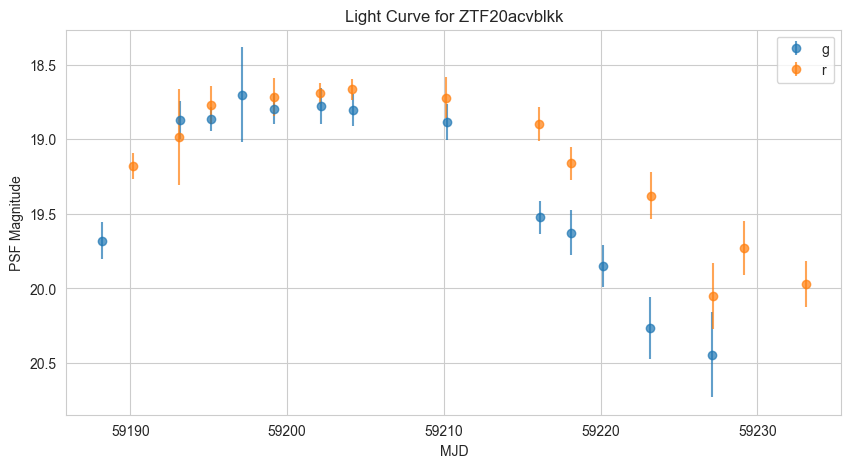

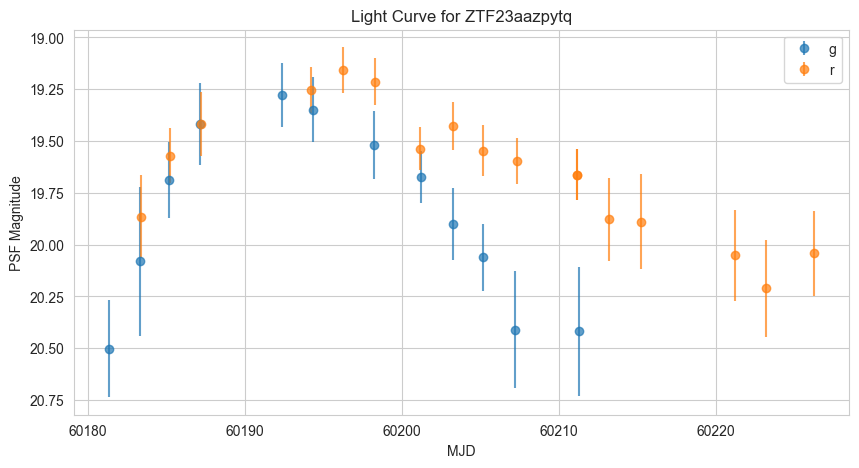

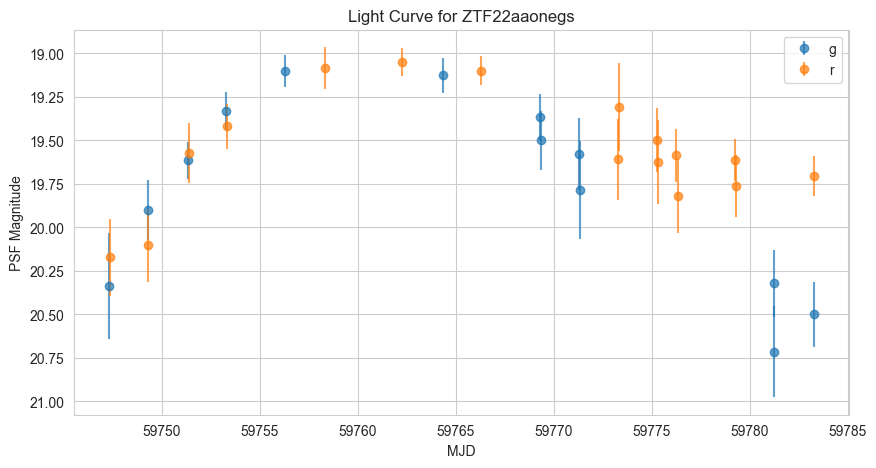

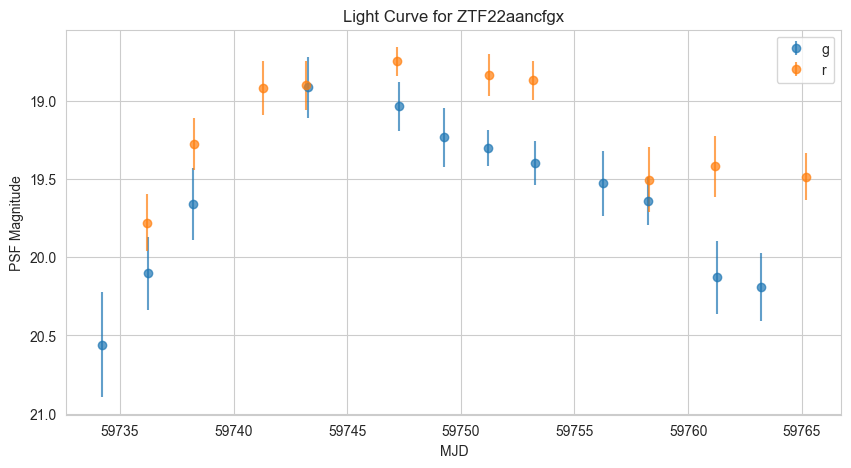

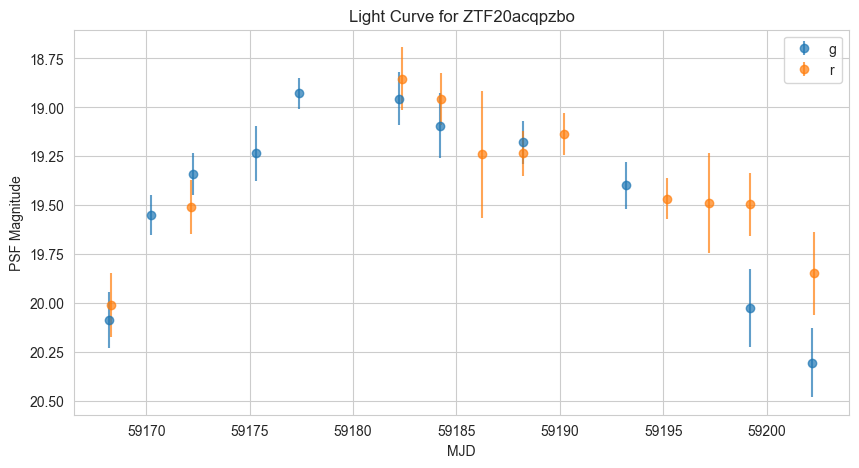

In [182]:
for oid, data in lightcurves.items():
    det = data["detections"]
    if det is not None and len(det) > 0:
        plot_lightcurve(det, oid)

### Now compare to min-med:

In [187]:
dimmad_minmed = DistanceAnomaly(
    cluster_agg="min",    
    metric_agg="median",
    normalize_scores=True
)

dimmad_minmed.fit(X_train, y_train)
scores_minmed = dimmad_minmed.score_samples(X_anom)


In [192]:
df_anom["dimmad_medmed"] = scores_medmed
df_anom["dimmad_minmed"] = scores_minmed

df_anom[["ZTFID", "dimmad_medmed", "dimmad_minmed"]].head()

,ZTFID,dimmad_medmed,dimmad_minmed
0,ZTF17aaaycpc,-0.004889,-0.033629
1,ZTF17aaahhwn,-0.001497,-0.017069
2,ZTF17aaazjab,-0.005370,-0.007216
3,ZTF17aadcedu,-0.002656,-0.012288
4,ZTF17aacpbmv,-0.001229,-0.011601


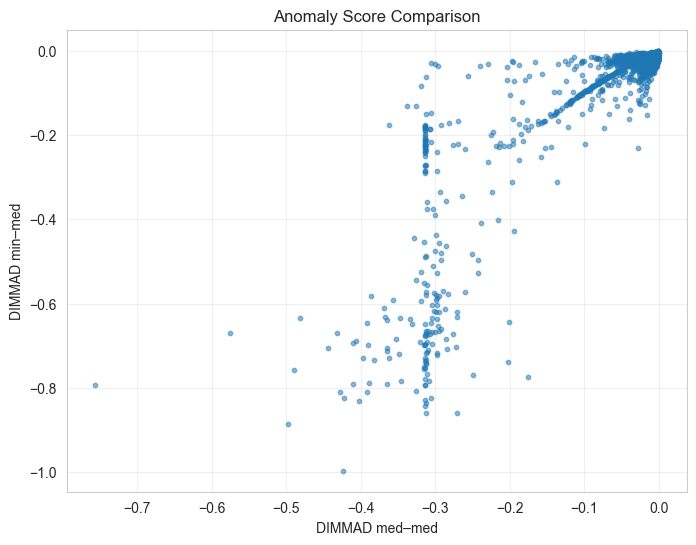

In [194]:
# Scatter plot:


plt.figure(figsize=(8,6))
plt.scatter(
    df_anom["dimmad_medmed"], 
    df_anom["dimmad_minmed"], 
    s=10, alpha=0.5
)
plt.xlabel("DIMMAD med–med")
plt.ylabel("DIMMAD min–med")
plt.title("Anomaly Score Comparison")
plt.grid(alpha=0.3)
plt.show()


In [196]:
p95_med = np.percentile(df_anom["dimmad_medmed"], 95)
p95_min = np.percentile(df_anom["dimmad_minmed"], 95)

df_both = df_anom[
    (df_anom["dimmad_medmed"] >= p95_med) &
    (df_anom["dimmad_minmed"] >= p95_min)
].sort_values("dimmad_medmed", ascending=False)

df_both[["ZTFID", "dimmad_medmed", "dimmad_minmed"]].head(20)


,ZTFID,dimmad_medmed,dimmad_minmed
1362,ZTF20acvblkk,-0.000049,-0.003632
10425,ZTF23aazpytq,-0.000164,-0.005735
6643,ZTF22aancfgx,-0.000200,-0.005616
1157,ZTF20acqpzbo,-0.000208,-0.001909
10121,ZTF23aasrebm,-0.000210,-0.005335
3943,ZTF21abhubze,-0.000218,-0.002451
4361,ZTF21abppeys,-0.000222,-0.006365
6117,ZTF22aahjcjr,-0.000231,-0.003574
431,ZTF20abgqobw,-0.000233,-0.004061
4906,ZTF21accohtt,-0.000235,-0.006768


In [198]:
df_ranked_med = df_anom.sort_values("dimmad_medmed", ascending=False)
df_ranked_min = df_anom.sort_values("dimmad_minmed", ascending=False)


In [200]:
df_anom.to_csv("DIMMAD_scores_medmed_minmed.csv", index=False)


### Compare lightcurves

In [203]:

p95_med = np.percentile(df_anom["dimmad_medmed"], 95)
p95_min = np.percentile(df_anom["dimmad_minmed"], 95)

df_both = df_anom[
    (df_anom["dimmad_medmed"] >= p95_med) &
    (df_anom["dimmad_minmed"] >= p95_min)
].copy()

df_both = df_both.sort_values("dimmad_medmed", ascending=False)

df_both[["ZTFID", "dimmad_medmed", "dimmad_minmed"]].head(10)

,ZTFID,dimmad_medmed,dimmad_minmed
1362,ZTF20acvblkk,-0.000049,-0.003632
10425,ZTF23aazpytq,-0.000164,-0.005735
6643,ZTF22aancfgx,-0.000200,-0.005616
1157,ZTF20acqpzbo,-0.000208,-0.001909
10121,ZTF23aasrebm,-0.000210,-0.005335
3943,ZTF21abhubze,-0.000218,-0.002451
4361,ZTF21abppeys,-0.000222,-0.006365
6117,ZTF22aahjcjr,-0.000231,-0.003574
431,ZTF20abgqobw,-0.000233,-0.004061
4906,ZTF21accohtt,-0.000235,-0.006768


In [205]:
topN = 5  # change to what you want
ztfids_top = df_both["ZTFID"].head(topN).tolist()
ztfids_top


['ZTF20acvblkk',
 'ZTF23aazpytq',
 'ZTF22aancfgx',
 'ZTF20acqpzbo',
 'ZTF23aasrebm']

In [207]:
import matplotlib.pyplot as plt

def plot_lightcurve(det, oid):
    plt.figure(figsize=(10,5))

    # fid → filter map
    fid_to_band = {1: "g", 2: "r", 3: "i"}
    det = det.copy()
    det["band"] = det["fid"].map(fid_to_band)

    for band in ["g", "r", "i"]:
        dfb = det[det["band"] == band]
        if dfb.empty:
            continue
        plt.errorbar(
            dfb["mjd"], dfb["magpsf"], yerr=dfb["sigmapsf"],
            fmt='o', label=band, alpha=0.7
        )

    plt.gca().invert_yaxis()
    plt.xlabel("MJD")
    plt.ylabel("PSF Magnitude")
    plt.title(f"{oid}  (DIMMAD Robust Anomaly)")
    plt.legend()
    plt.tight_layout()
    plt.show()



Fetching light curve for robust anomaly: ZTF20acvblkk
Saved ZTF20acvblkk: 26 detections, 30 non-detections


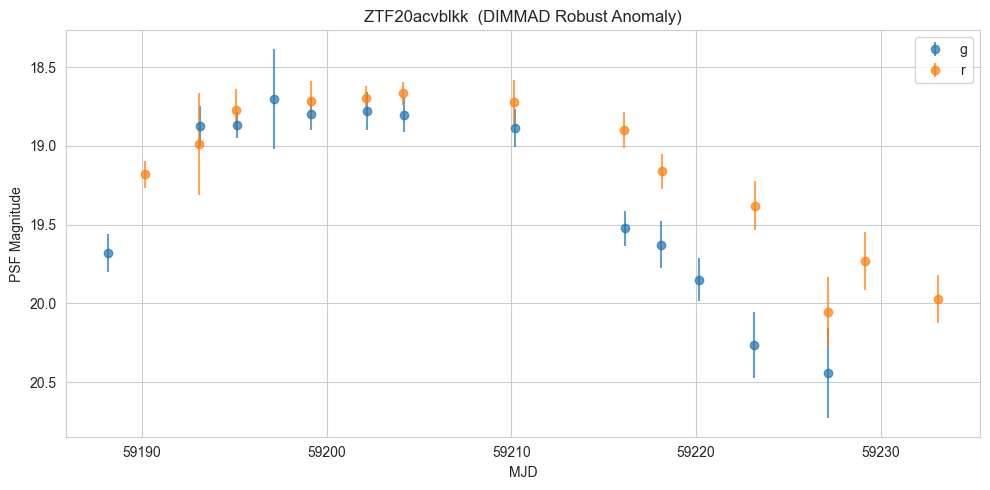


Fetching light curve for robust anomaly: ZTF23aazpytq
Saved ZTF23aazpytq: 29 detections, 24 non-detections


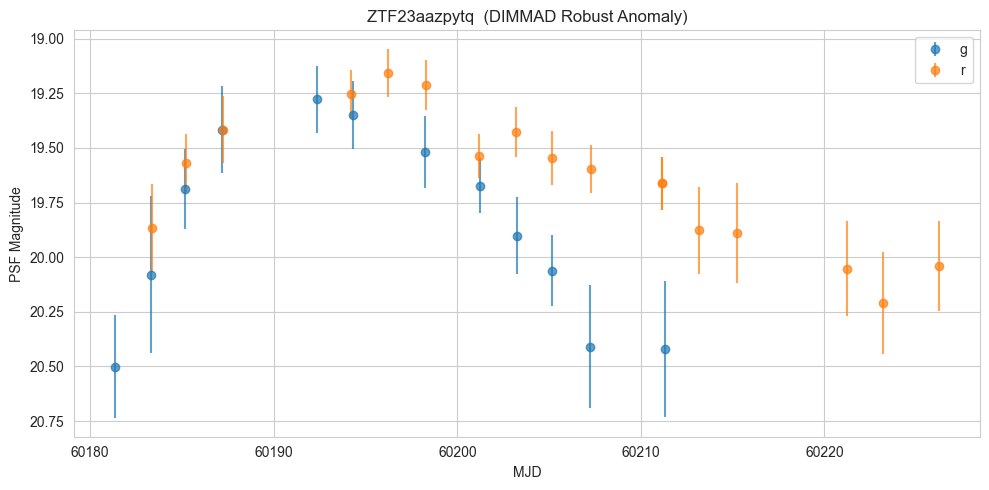


Fetching light curve for robust anomaly: ZTF22aancfgx
Saved ZTF22aancfgx: 22 detections, 18 non-detections


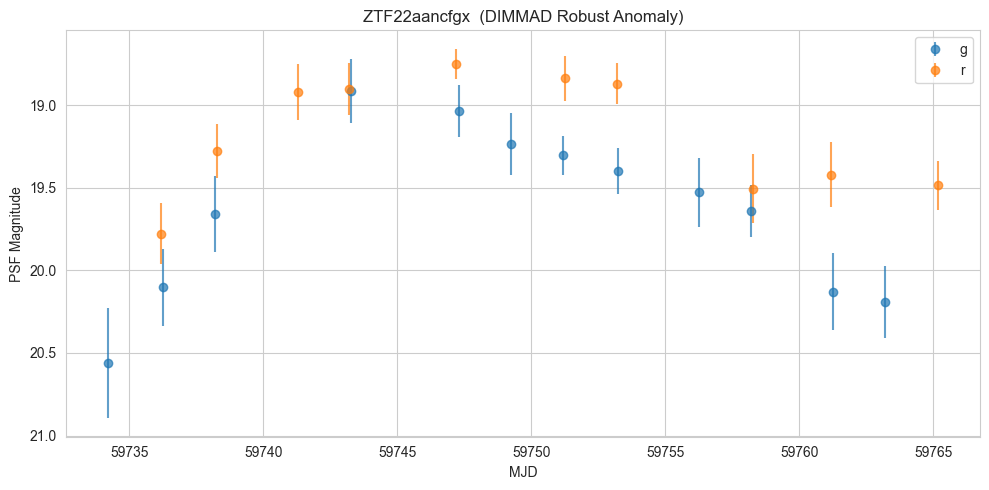


Fetching light curve for robust anomaly: ZTF20acqpzbo
Saved ZTF20acqpzbo: 22 detections, 22 non-detections


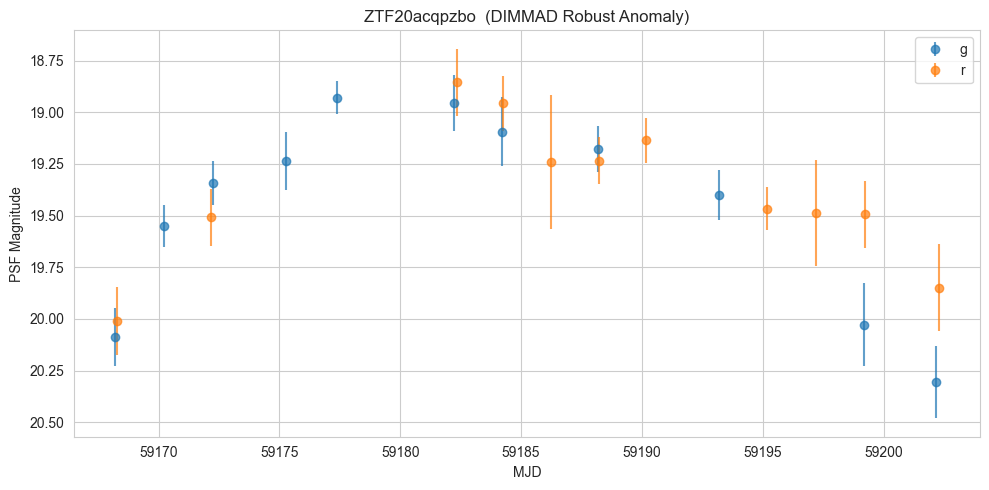


Fetching light curve for robust anomaly: ZTF23aasrebm
Saved ZTF23aasrebm: 19 detections, 5 non-detections


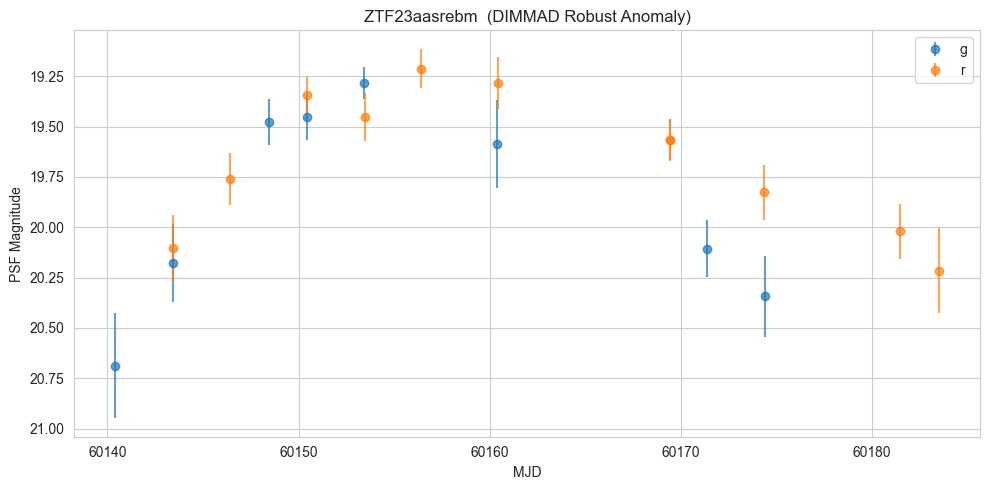


Fetching light curve for robust anomaly: ZTF20acvblkk
Saved ZTF20acvblkk: 26 detections, 30 non-detections


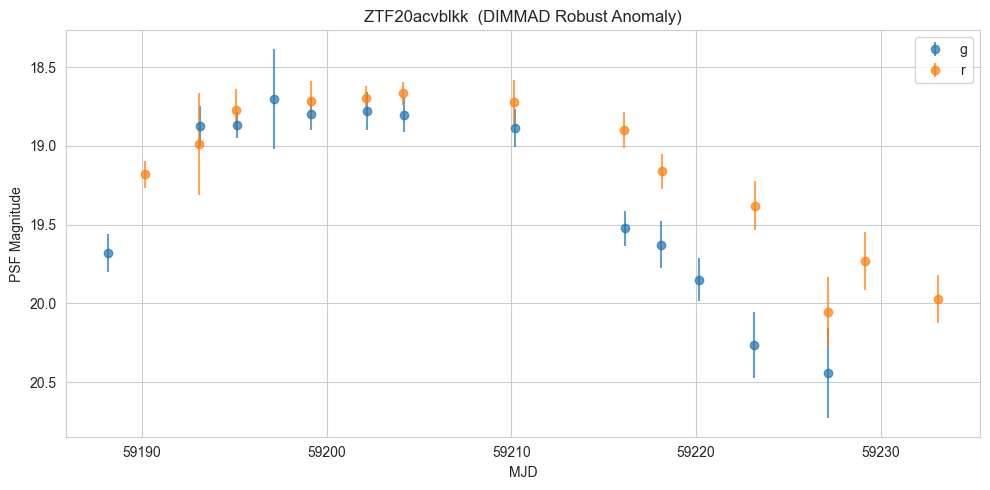


Fetching light curve for robust anomaly: ZTF23aazpytq
Saved ZTF23aazpytq: 29 detections, 24 non-detections


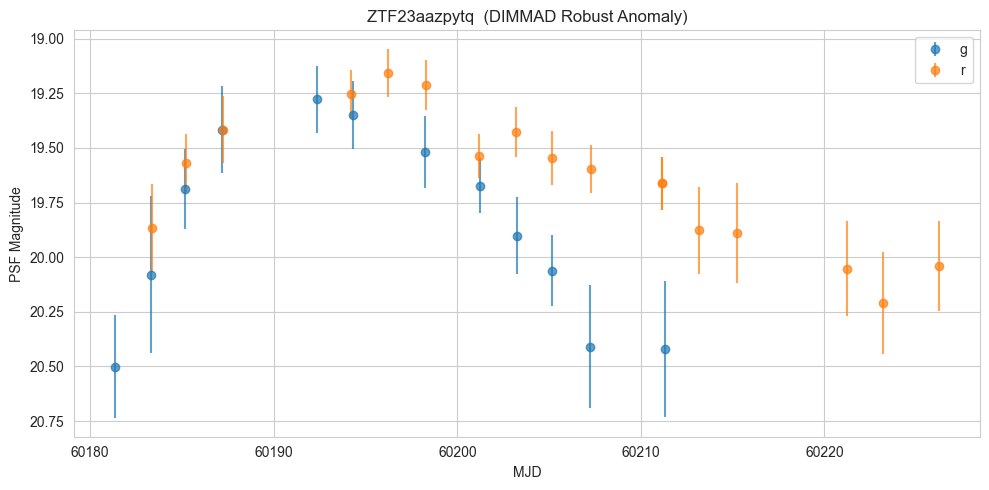


Fetching light curve for robust anomaly: ZTF22aancfgx
Saved ZTF22aancfgx: 22 detections, 18 non-detections


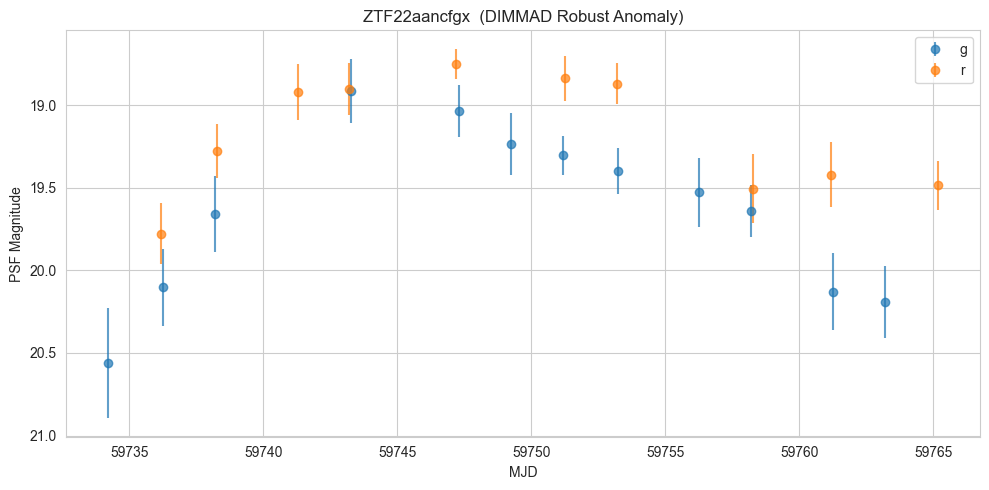


Fetching light curve for robust anomaly: ZTF20acqpzbo
Saved ZTF20acqpzbo: 22 detections, 22 non-detections


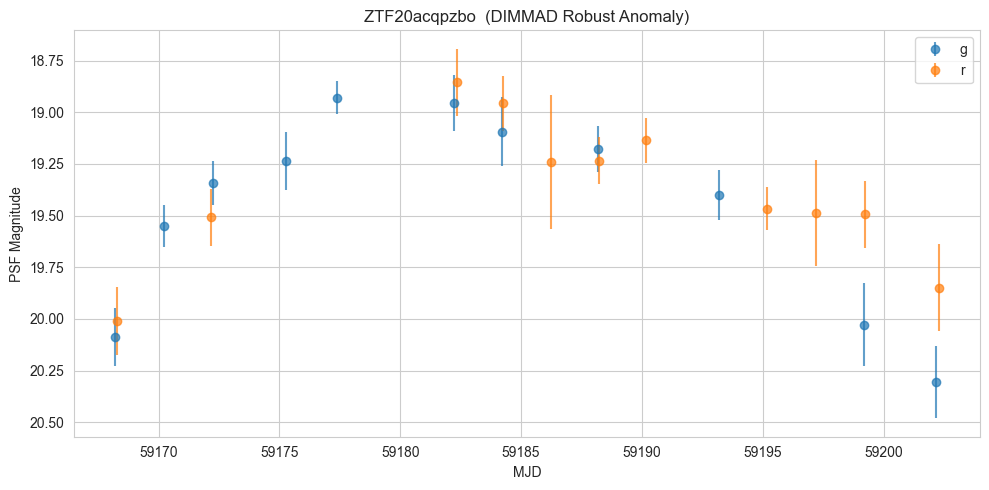


Fetching light curve for robust anomaly: ZTF23aasrebm
Saved ZTF23aasrebm: 19 detections, 5 non-detections


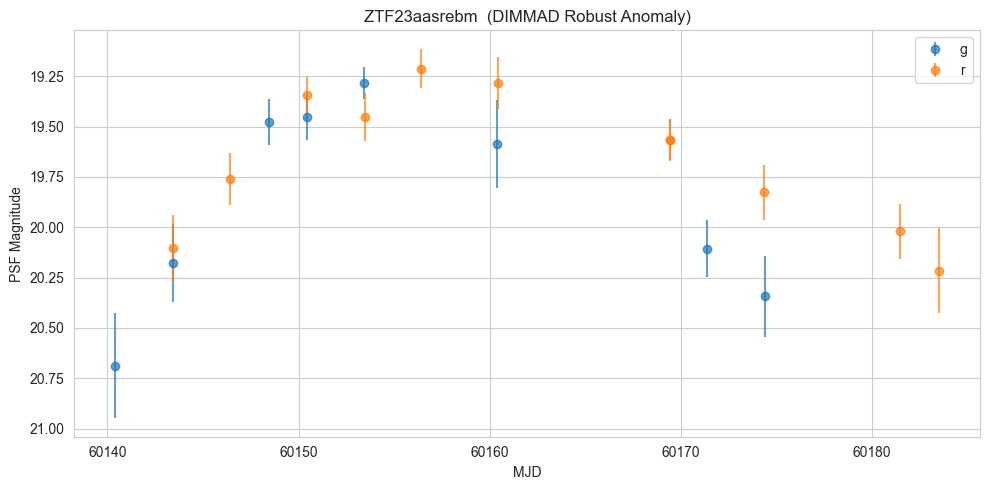

In [209]:
robust_lightcurves = {}

for oid in ztfids_top:
    print(f"\nFetching light curve for robust anomaly: {oid}")
    det, nond = fetch_lightcurve(oid)
    robust_lightcurves[oid] = det

    if det is not None and len(det) > 0:
        plot_lightcurve(det, oid)
robust_lightcurves = {}

for oid in ztfids_top:
    print(f"\nFetching light curve for robust anomaly: {oid}")
    det, nond = fetch_lightcurve(oid)
    robust_lightcurves[oid] = det

    if det is not None and len(det) > 0:
        plot_lightcurve(det, oid)


### Images:

In [216]:
from alerce.core import Alerce
import requests
from PIL import Image
from io import BytesIO
import os

client = Alerce()

In [222]:
import requests
from PIL import Image
from io import BytesIO
import os

def fetch_cutouts(oid, save_dir="cutouts"):
    os.makedirs(save_dir, exist_ok=True)

    cutout_types = {
        "science": "science",
        "reference": "ref",
        "difference": "diff"
    }

    saved_files = {}

    for label, fmt in cutout_types.items():
        url = f"https://alerce.online/api/cutout/{oid}?format={fmt}"
        
        try:
            resp = requests.get(url)
            resp.raise_for_status()

            # Load image
            img = Image.open(BytesIO(resp.content))

            fname = os.path.join(save_dir, f"{oid}_{label}.png")
            img.save(fname)
            saved_files[label] = fname

            print(f"Saved {label} cutout for {oid} → {fname}")

        except Exception as e:
            print(f"Could not fetch {label} cutout for {oid}: {e}")

    return saved_files


In [224]:
for oid in ztfids_top:
    print(f"\nFetching cutouts for {oid} ...")
    fetch_cutouts(oid, save_dir="robust_anomaly_cutouts")



Fetching cutouts for ZTF20acvblkk ...
Could not fetch science cutout for ZTF20acvblkk: 403 Client Error: Forbidden for url: https://alerce.online/api/cutout/ZTF20acvblkk?format=science
Could not fetch reference cutout for ZTF20acvblkk: 403 Client Error: Forbidden for url: https://alerce.online/api/cutout/ZTF20acvblkk?format=ref
Could not fetch difference cutout for ZTF20acvblkk: 403 Client Error: Forbidden for url: https://alerce.online/api/cutout/ZTF20acvblkk?format=diff

Fetching cutouts for ZTF23aazpytq ...
Could not fetch science cutout for ZTF23aazpytq: 403 Client Error: Forbidden for url: https://alerce.online/api/cutout/ZTF23aazpytq?format=science
Could not fetch reference cutout for ZTF23aazpytq: 403 Client Error: Forbidden for url: https://alerce.online/api/cutout/ZTF23aazpytq?format=ref
Could not fetch difference cutout for ZTF23aazpytq: 403 Client Error: Forbidden for url: https://alerce.online/api/cutout/ZTF23aazpytq?format=diff

Fetching cutouts for ZTF22aancfgx ...
Could

In [226]:
client = Alerce()
client.query_objects(oid="ZTF20acvblkk")


,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,...,lastmjd,deltajd,meanra,meandec,sigmara,sigmadec,class,classifier,probability,step_id_corr
0,ZTF20acvblkk,34,870,59188.172083,59233.116319,False,False,26,0.036554,None,...,59233.116319,44.944236,349.738952,33.780686,0.000036,0.000059,None,None,None,corr_bulk_0.0.1


### Look at distributions etc

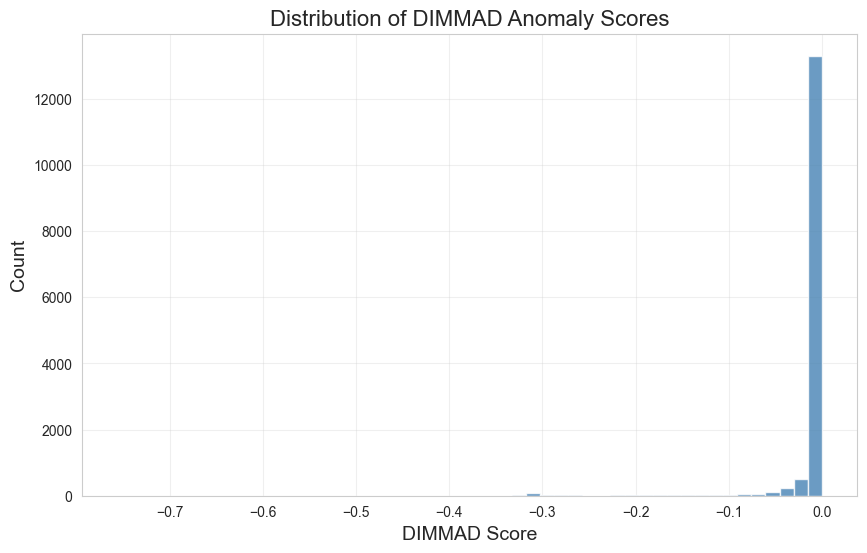

In [162]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df_anom["dimmad_score"], bins=50, color='steelblue', alpha=0.8)
plt.xlabel("DIMMAD Score", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution of DIMMAD Anomaly Scores", fontsize=16)
plt.grid(alpha=0.3)
plt.show()


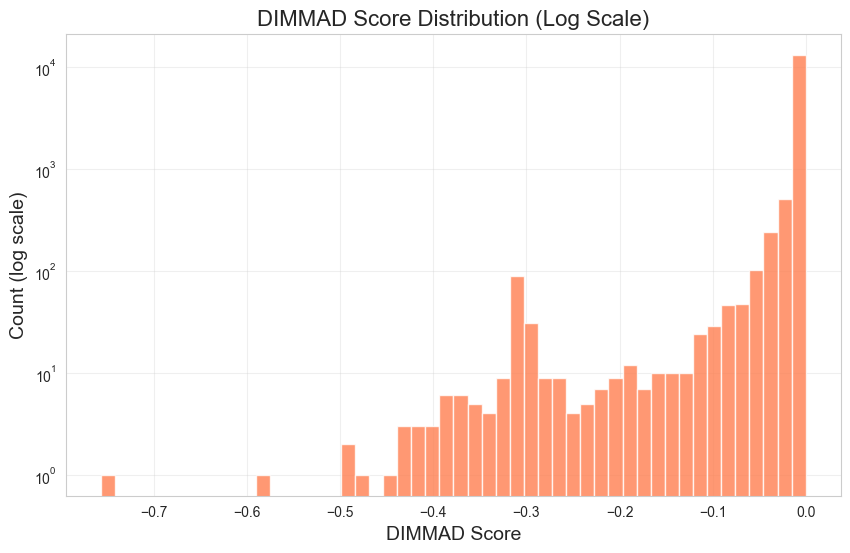

In [149]:
plt.figure(figsize=(10,6))
plt.hist(df_anom["dimmad_score"], bins=50, color='coral', alpha=0.8)
plt.yscale("log")
plt.xlabel("DIMMAD Score", fontsize=14)
plt.ylabel("Count (log scale)", fontsize=14)
plt.title("DIMMAD Score Distribution (Log Scale)", fontsize=16)
plt.grid(alpha=0.3)
plt.show()


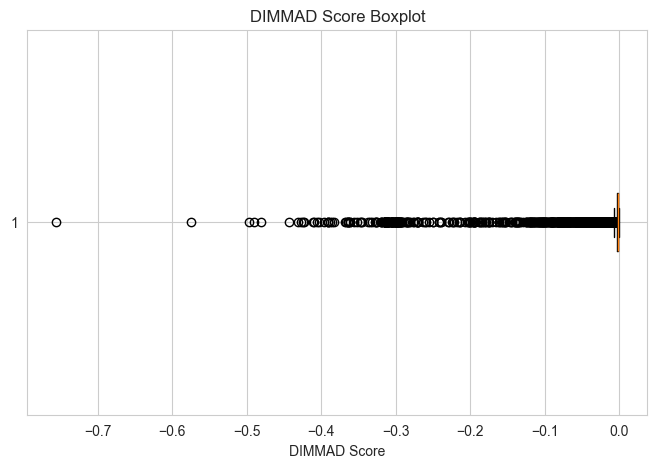

In [151]:
plt.figure(figsize=(8,5))
plt.boxplot(df_anom["dimmad_score"], vert=False)
plt.xlabel("DIMMAD Score")
plt.title("DIMMAD Score Boxplot")
plt.show()


In [153]:
threshold_95 = np.percentile(df_anom["dimmad_score"], 95)
threshold_98 = np.percentile(df_anom["dimmad_score"], 98)
threshold_99 = np.percentile(df_anom["dimmad_score"], 99)

print("95th percentile threshold:", threshold_95)
print("98th percentile threshold:", threshold_98)
print("99th percentile threshold:", threshold_99)


95th percentile threshold: -0.0006770947095792232
98th percentile threshold: -0.0005188342942314379
99th percentile threshold: -0.0004340924240945712
